# Phase 2: Exploratory Data Analysis (EDA) & Hypothesis testing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setup Environment 
plt.style.use('seaborn-v0_8')
sns.set_theme(context='talk', style='whitegrid', palette='colorblind')
pd.options.display.float_format = '{:.2f}'.format

# Load the Enriched Data
df = pd.read_csv('../data/processed/f1_enriched_data.csv')


## Step 1: We explore the dataset

In [20]:
# Lets look at the structure of the dataset
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
df.head()

Rows: 2839, Columns: 34


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,lat,lng,driver_name,constructor_name,position_quali,positions_gained,temp_max,temp_mean,rainfall,humidity
0,23782,989,20,6,5,3,1,1,1,25.00,...,-37.85,144.97,Sebastian Vettel,Ferrari,3.00,2,23.40,19.90,5.20,59.46
1,23783,989,1,131,44,1,2,2,2,18.00,...,-37.85,144.97,Lewis Hamilton,Mercedes,1.00,-1,23.40,19.90,5.20,59.46
2,23784,989,8,6,7,2,3,3,3,15.00,...,-37.85,144.97,Kimi Räikkönen,Ferrari,2.00,-1,23.40,19.90,5.20,59.46
3,23785,989,817,9,3,8,4,4,4,12.00,...,-37.85,144.97,Daniel Ricciardo,Red Bull,5.00,4,23.40,19.90,5.20,59.46
4,23786,989,4,1,14,10,5,5,5,10.00,...,-37.85,144.97,Fernando Alonso,McLaren,11.00,5,23.40,19.90,5.20,59.46


##### We check the structure, data types, and missing values

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2839 entries, 0 to 2838
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   resultId          2839 non-null   int64  
 1   raceId            2839 non-null   int64  
 2   driverId          2839 non-null   int64  
 3   constructorId     2839 non-null   int64  
 4   number            2839 non-null   int64  
 5   grid              2839 non-null   int64  
 6   position          2839 non-null   str    
 7   positionText      2839 non-null   str    
 8   positionOrder     2839 non-null   int64  
 9   points            2839 non-null   float64
 10  laps              2839 non-null   int64  
 11  time              2839 non-null   str    
 12  milliseconds      2839 non-null   str    
 13  fastestLap        2839 non-null   str    
 14  rank              2839 non-null   int64  
 15  fastestLapTime    2839 non-null   str    
 16  fastestLapSpeed   2839 non-null   str    
 17  status

In [22]:
analysis_cols = [
    'grid', 'positionOrder', 'points', 'positions_gained', 
    'temp_max', 'temp_mean', 'rainfall', 'humidity', 'year',
    'laps', 'fastestLap', 'fastestLapSpeed'
]

# Convert fastestLap to integer
df['fastestLap'] = pd.to_numeric(df['fastestLap'], errors='coerce')

# Convert fastestLapSpeed to float
df['fastestLapSpeed'] = pd.to_numeric(df['fastestLapSpeed'], errors='coerce')

display(df[analysis_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
grid,2839.00,10.06,5.82,0.00,5.00,10.00,15.00,20.00
positionOrder,2839.00,10.50,5.77,1.00,5.50,10.00,15.00,20.00
points,2839.00,5.07,7.22,0.00,0.00,0.50,9.00,26.00
positions_gained,2839.00,-0.43,5.48,-20.00,-2.00,0.00,3.00,18.00
temp_max,2839.00,24.24,5.17,8.70,20.20,23.90,28.50,40.50
temp_mean,2839.00,19.60,4.61,6.00,15.90,19.60,23.30,32.80
rainfall,2839.00,2.22,6.87,0.00,0.00,0.00,1.90,70.30
humidity,2839.00,69.26,11.95,28.04,61.17,71.04,77.88,95.50
year,2839.00,2021.07,2.03,2018.00,2019.00,2021.00,2023.00,2024.00
laps,2839.00,54.62,17.36,0.00,51.00,57.00,68.00,87.00


In [24]:
# Lets check for missing data
missing_probs = df.isna().mean().sort_values(ascending=False).head(10)
display(missing_probs)

fastestLap        0.04
fastestLapSpeed   0.04
position_quali    0.00
resultId          0.00
raceId            0.00
driverId          0.00
position          0.00
positionText      0.00
number            0.00
constructorId     0.00
dtype: float64

## Step 2: Graphs

### EDA 1: Trend of Average Finishing Position by Starting Grid
**Purpose:** To visualize the baseline predictability of a Formula 1 race. 
**Analysis:** The red dashed line represents "perfect predictability" (where a driver finishes exactly where they started). The blue line shows the actual average finishing position for each grid slot. We can observe how closely the actual results track the perfect prediction. This sets the foundation for our first hypothesis test.

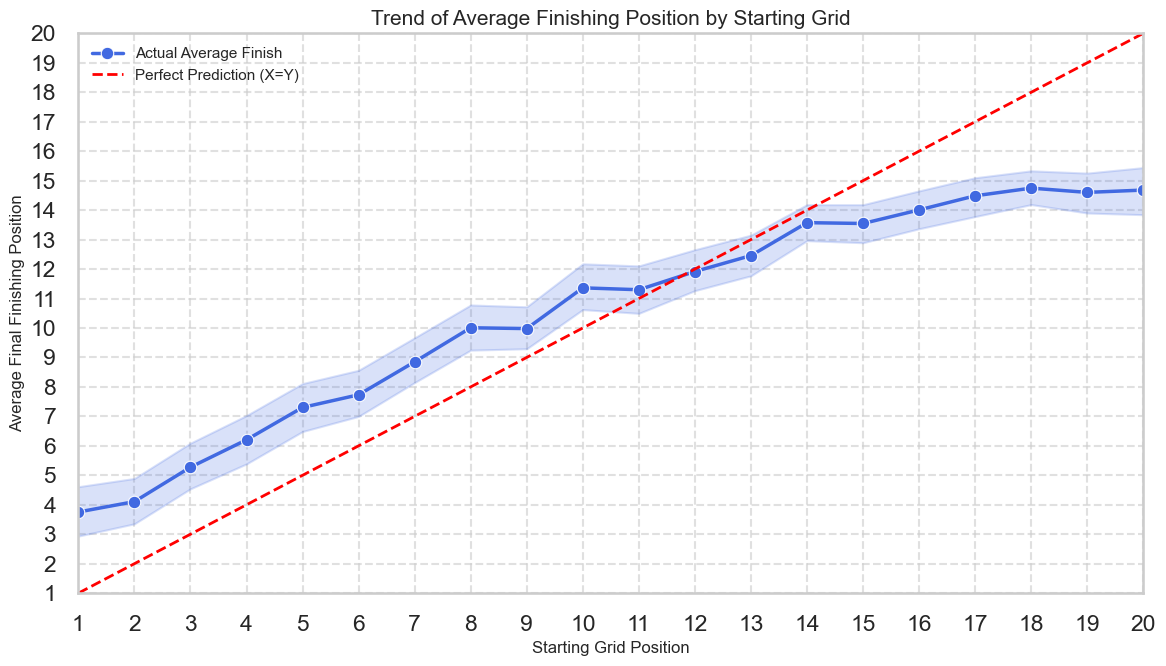

In [ ]:
plt.figure(figsize=(12, 7))

sns.lineplot(
    data=df, 
    x='grid', 
    y='positionOrder', 
    marker='o',          # Adds dots at each data point for clarity
    color='royalblue', 
    linewidth=2.5,
    label='Actual Average Finish'
)

# Add the baseline reference line 
plt.plot([1, 20], [1, 20], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (X=Y)')

# Formatting 
plt.title('Trend of Average Finishing Position by Starting Grid', fontsize=15)
plt.xlabel('Starting Grid Position', fontsize=12)
plt.ylabel('Average Final Finishing Position', fontsize=12)

# Lock axes to the 1-20 F1 grid format
plt.xlim(1, 20)
plt.ylim(1, 20)
plt.xticks(range(1, 21)) # Force x-axis to show every grid position
plt.yticks(range(1, 21))

plt.legend(loc='upper left', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### EDA 2: Average Positions Gained by Constructor
**Purpose:** To explore the categorical impact of the constructor (team) on race-day performance.
**Analysis:** This chart highlights teams' average net change in positions. Teams on the right side of the red zero-line consistently move forward through the field, while teams on the left tend to fall backward from their qualifying positions. This visualizes the relationship we will formally test in our Chi-Square analysis regarding constructor resiliency.

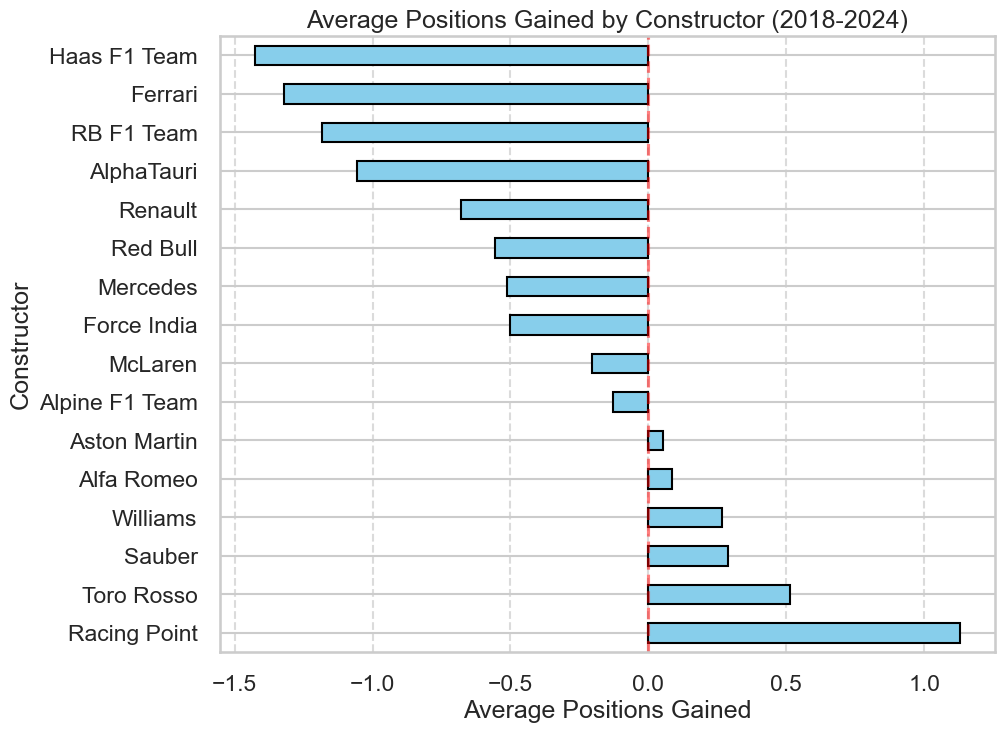

In [ ]:
# Calculate average positions gained per team
constructor_performance = df.groupby('constructor_name')['positions_gained'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 8))

# Horizontal bar chart 
constructor_performance.plot(kind='barh', color='skyblue', edgecolor='black')

plt.title('Average Positions Gained by Constructor (2018-2024)')
plt.xlabel('Average Positions Gained')
plt.ylabel('Constructor')
plt.axvline(0, color='red', linestyle='--', alpha=0.5)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### EDA 3: Distribution of Positions Gained/Lost (Dry vs. Wet)
**Purpose:** To visualize how environmental conditions affect the spread and volatility of race outcomes.
**Analysis:** By comparing the box plots, we can see the difference in variance between dry and wet conditions. A wider box and longer whiskers in the "Wet" category visually indicates higher race volatility (more chaos and position swapping), which we will mathematically verify using our Two-Sample T-Test for weather disruption.

/var/folders/nf/p9tngrvd78g0n1xh697rvsm80000gn/T/ipykernel_26529/1964623252.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='weather_type', y='positions_gained', palette='Set2')


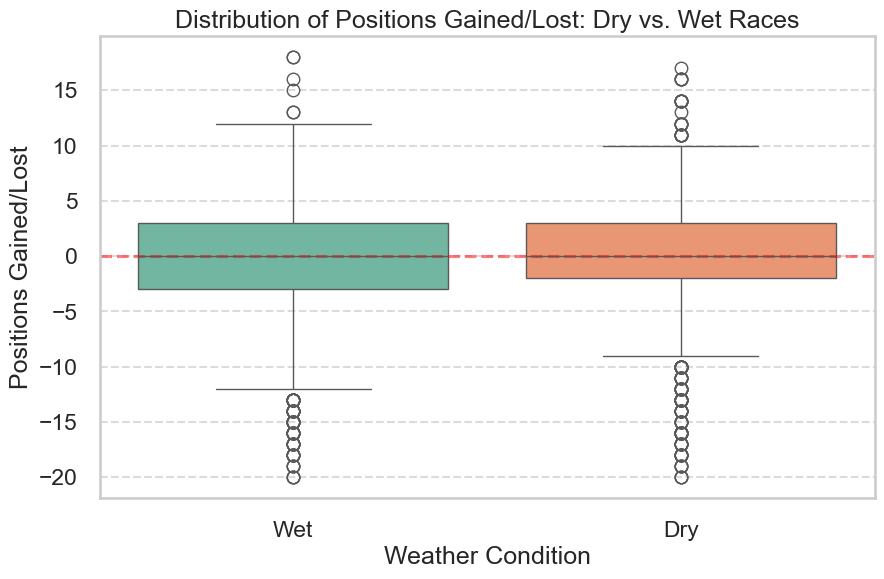

In [ ]:
# Create Box Plot to compare performance distribution by weather
plt.figure(figsize=(10, 6))

# Define 'is_wet' for clear categorical mapping
df['weather_type'] = df['rainfall'].apply(lambda x: 'Wet' if x > 0 else 'Dry')


sns.boxplot(data=df, x='weather_type', y='positions_gained', palette='Set2')

plt.title('Distribution of Positions Gained/Lost: Dry vs. Wet Races')
plt.xlabel('Weather Condition')
plt.ylabel('Positions Gained/Lost')
plt.axhline(0, color='red', linestyle='--', alpha=0.5) # Reference line for 'No Change'
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### EDA 4: F1 Race Volatility (Grid vs Finish with Weather)
**Purpose:** To map four key variables (Starting Grid, Final Position, Rainfall, and Temperature) onto a single visualization.
**Analysis:** Points falling directly on the red dashed line represent perfectly predictable outcomes. By mapping rainfall to color and temperature to bubble size, we can visually scan for clusters of weather-driven outliers. This allows us to observe if the points furthest from the predictability line consistently share specific environmental characteristics.

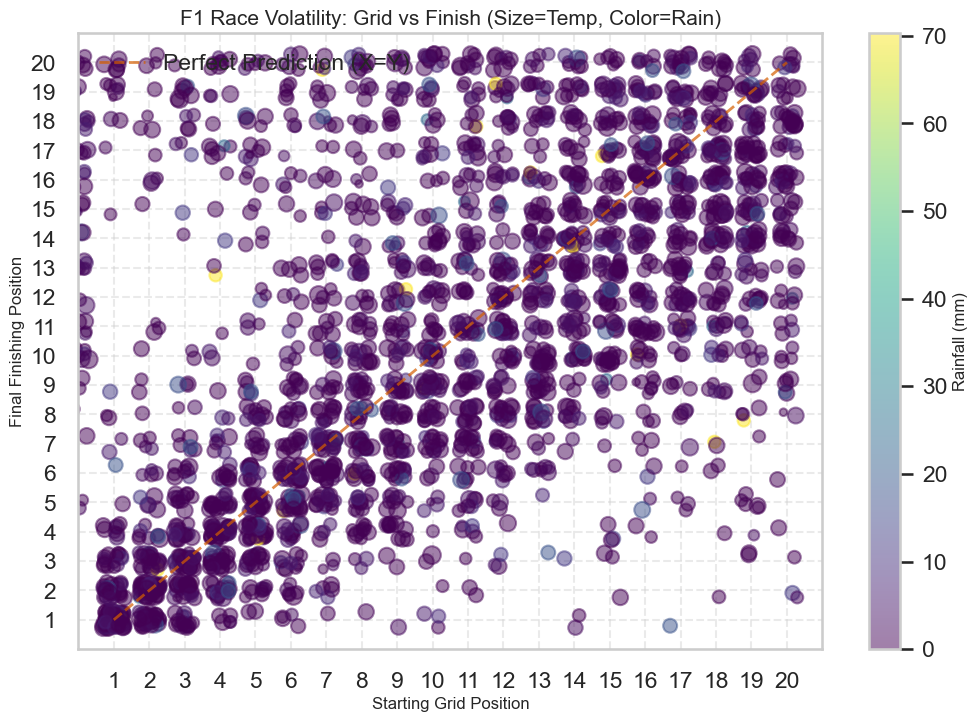

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(12, 8))

# Add a small amount of random jitter to separate the overlapping points
jitter_x = df['grid'] + np.random.uniform(-0.3, 0.3, size=len(df))
jitter_y = df['positionOrder'] + np.random.uniform(-0.3, 0.3, size=len(df))

# Plot using the jittered coordinates
scatter = plt.scatter(
    jitter_x, 
    jitter_y, 
    c=df['rainfall'], 
    s=df['temp_mean'] * 5, 
    alpha=0.5,  # Bumped up slightly now that points are separated
    cmap='viridis'
)

# Colorbar for Rainfall
cbar = plt.colorbar(scatter)
cbar.set_label('Rainfall (mm)', fontsize=12)

# Perfect Prediction Line (Keep this on the exact integers)
plt.plot([1, 20], [1, 20], 'r--', alpha=0.7, linewidth=2, label='Perfect Prediction (X=Y)')

plt.title('F1 Race Volatility: Grid vs Finish (Size=Temp, Color=Rain)', fontsize=15)
plt.xlabel('Starting Grid Position', fontsize=12)
plt.ylabel('Final Finishing Position', fontsize=12)

# Lock axes to keep the grid clean
plt.xlim(0, 21)
plt.ylim(0, 21)
plt.xticks(range(1, 21)) 
plt.yticks(range(1, 21))

plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

### EDA 5: Distribution of Positions Gained/Lost
**Purpose:** To understand the fundamental shape and distribution of our primary target variable.
**Analysis:** This histogram (overlaid with a Kernel Density Estimate) shows the frequency of positions gained or lost across all races in the dataset. Verifying that this distribution roughly follows a normal curve (centered around zero) is a crucial prerequisite for trusting the parametric statistical tests (like the T-Test) applied later in the notebook.

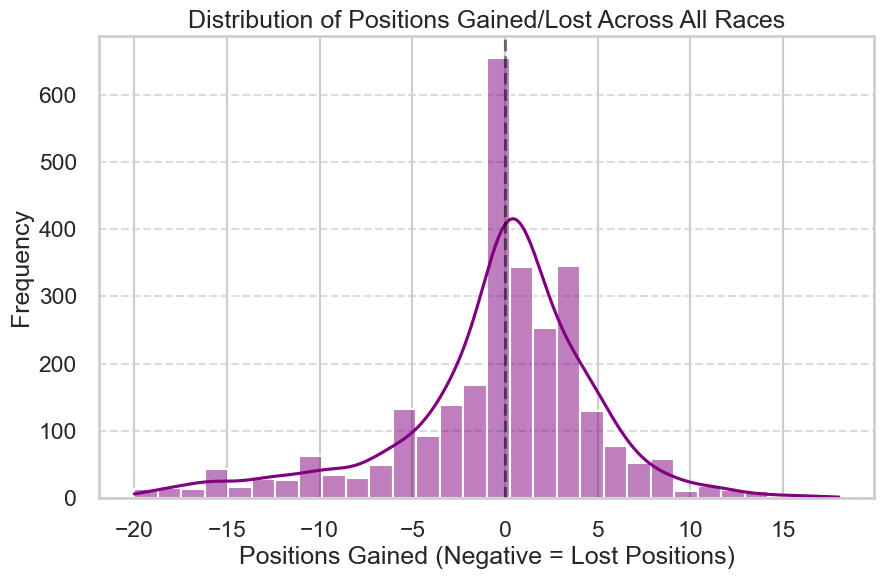

In [24]:
plt.figure(figsize=(10, 6))

# Histogram with KDE overlay to show distribution shape
sns.histplot(data=df, x='positions_gained', bins=30, kde=True, color='purple')

plt.title('Distribution of Positions Gained/Lost Across All Races')
plt.xlabel('Positions Gained (Negative = Lost Positions)')
plt.ylabel('Frequency')
plt.axvline(0, color='black', linestyle='--', alpha=0.5) # Reference line for 0 change

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### EDA 6: Correlation Matrix of Race & Environmental Factors
**Purpose:** To provide a mathematical overview of the linear relationships between all continuous numerical variables in the dataset.
**Analysis:** This heatmap allows us to instantly spot strong or weak correlations. For example, a high positive correlation between `grid` and `positionOrder` confirms the predictive power of qualifying. Conversely, we can observe the raw correlation coefficients between environmental factors (like `rainfall` or `humidity`) and `positions_gained` before moving into formal hypothesis testing.

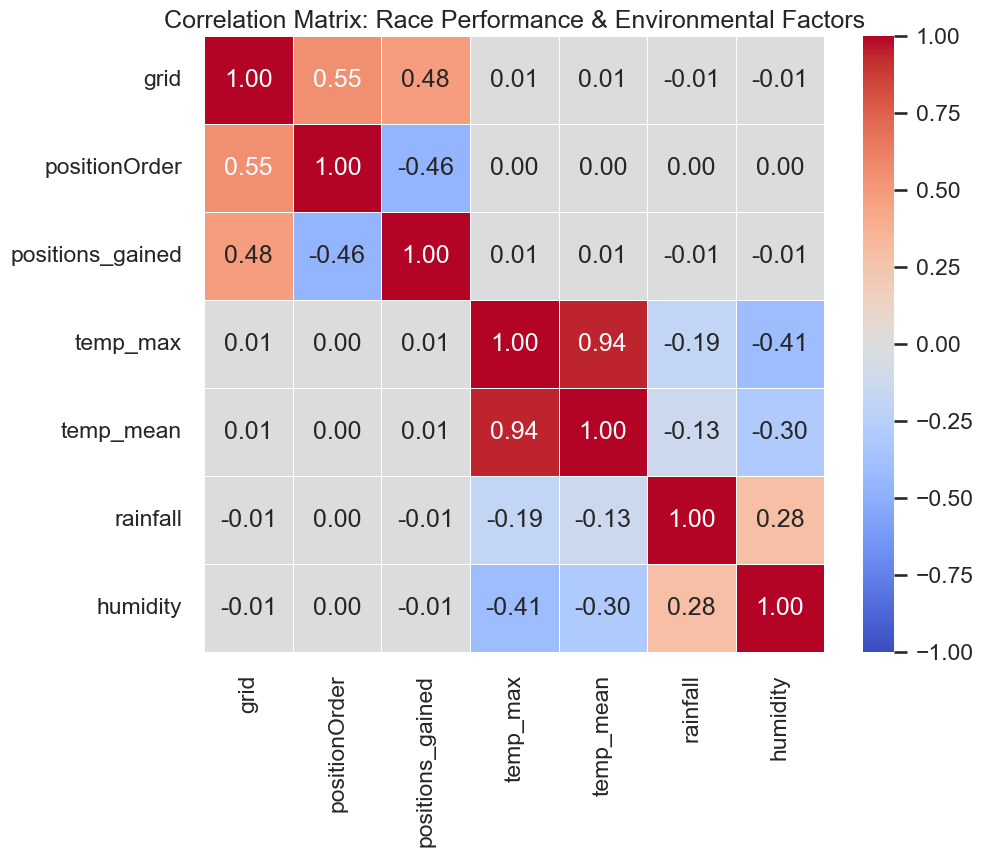

In [25]:
plt.figure(figsize=(10, 8))

# Select only the relevant numerical columns for the heatmap
numerical_cols = ['grid', 'positionOrder', 'positions_gained', 'temp_max', 'temp_mean', 'rainfall', 'humidity']
corr_matrix = df[numerical_cols].corr()

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, linewidths=0.5)

plt.title('Correlation Matrix: Race Performance & Environmental Factors')
plt.show()

### Step 3: Hypothesis testing

### Question 1: Predictive Power of Qualifying
**Two-Sample T-test**
Determines whether the average difference between two groups is really significant or if it is due to random chance.

**Question:** Is there a significant difference in the final race result between drivers who qualify in the top 10 versus those who qualify in the bottom 10?

Our hypotheses are:
* **$H_0$:** There is no significant difference between the mean finishing positions of top 10 starters and bottom 10 starters.
* **$H_A$:** There is a significant difference between the mean finishing positions of top 10 starters and bottom 10 starters.

In [17]:
import scipy.stats as stats

test_type = "positionOrder"
top_10 = df[df["grid"] <= 10][test_type].dropna()
bottom_10 = df[df["grid"] > 10][test_type].dropna()

print(f"mean finish position of top 10 starters: {top_10.mean():.2f}")
print(f"mean finish position of bottom 10 starters: {bottom_10.mean():.2f}")

t_stat, p = stats.ttest_ind(top_10, bottom_10, equal_var=False)
print(f"p-value: {p}")

if p < 0.05:
    print("\nWe reject the null hypothesis. There is a significant difference in finish position.")
else:
    print("\nWe fail to reject the null hypothesis. There is no significant difference in finish position.")

mean finish position of top 10 starters: 7.76
mean finish position of bottom 10 starters: 13.49
p-value: 5.479062589336958e-179

We reject the null hypothesis. There is a significant difference in finish position.


### Question 2: Weather Volatility Impact
**Two-Sample T-test**
Determines whether the average difference between two groups is really significant or if it is due to random chance.

**Question:** Do weather conditions significantly change the average number of positions a driver gains or loses during a race?

Our hypotheses are:
* **$H_0$:** There is no significant difference in the mean positions gained between dry races and wet races.
* **$H_A$:** There is a significant difference in the mean positions gained between dry races and wet races.

In [18]:
test_type = "positions_gained"
dry_races = df[df["rainfall"] == 0][test_type].dropna()
wet_races = df[df["rainfall"] > 0][test_type].dropna()

print(f"mean positions gained in dry races: {dry_races.mean():.2f}")
print(f"mean positions gained in wet races: {wet_races.mean():.2f}")

t_stat, p = stats.ttest_ind(dry_races, wet_races, equal_var=False)
print(f"p-value: {p}")

if p < 0.05:
    print("\nWe reject the null hypothesis. There is a significant difference in positions gained between dry and wet races.")
else:
    print("\nWe fail to reject the null hypothesis. There is no significant difference in positions gained between dry and wet races.")

mean positions gained in dry races: -0.34
mean positions gained in wet races: -0.53
p-value: 0.3618991821607601

We fail to reject the null hypothesis. There is no significant difference in positions gained between dry and wet races.


### Question 3: Constructor Resiliency
**Chi-Square Test of Independence**
The Chi-Square Test of Independence is a statistical test used to determine if two categorical variables are independent or related.

**Question:** Is a driver's ability to outperform their starting grid position dependent on which constructor (team) they race for?

Our hypotheses are:
* **$H_0$:** The two variables are independent (i.e. there is no relationship between the constructor and outperforming the grid)
* **$H_A$:** The two variables are dependent (i.e. there is a relationship between the constructor and outperforming the grid)

In [19]:
import pandas as pd

df["outperformed_grid"] = df["positions_gained"] > 0
contingency_q3 = pd.crosstab(df["constructor_name"], df["outperformed_grid"])

chi2, p, dof, expected = stats.chi2_contingency(contingency_q3)
print(f"p-value: {p}")

if p < 0.05:
    print("\nWe reject the null hypothesis. There is an association between constructor and outperforming the grid.")
else:
    print("\nWe fail to reject the null hypothesis. There is no association between constructor and outperforming the grid.")

p-value: 0.00011130743471060432

We reject the null hypothesis. There is an association between constructor and outperforming the grid.


### Question 4: Circuit Volatility
**Chi-Square Test of Independence**
The Chi-Square Test of Independence is a statistical test used to determine if two categorical variables are independent or related.

**Question:** Are some circuits associated with higher race volatility (drivers gaining or losing a large amount of positions) than others?

Our hypotheses are:
* **$H_0$:** The two variables are independent (i.e. there is no relationship between the circuit and high race volatility)
* **$H_A$:** The two variables are dependent (i.e. there is a relationship between the circuit and high race volatility)

In [20]:
df["high_volatility"] = abs(df["positions_gained"]) > 3
contingency_q4 = pd.crosstab(df["circuit_name"], df["high_volatility"])

chi2, p, dof, expected = stats.chi2_contingency(contingency_q4)
print(f"p-value: {p}")

if p < 0.05:
    print("\nWe reject the null hypothesis. There is an association between circuit and high volatility.")
else:
    print("\nWe fail to reject the null hypothesis. There is no association between circuit and high volatility.")

p-value: 0.00022634469303686963

We reject the null hypothesis. There is an association between circuit and high volatility.
